In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

results = json.load(open("./data/results.json"))
df = pd.DataFrame(results)

In [3]:
def compute_metrics(df, threshold=0.5):

    y = df.y_true.values
    p = df.p_pred.values

    y_pred = (p > threshold).astype(int)

    return {
        "auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "f1": f1_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "brier": brier_score_loss(y, p),
        "n": len(df)
    }

In [4]:
metrics = {}

metrics["overall"] = compute_metrics(df)

for doc_type in df.doc_type.unique():
    metrics[doc_type] = compute_metrics(df[df.doc_type == doc_type])

In [18]:
table = pd.DataFrame(metrics).T

table = table.astype({ 'n': int })

latex = table.to_latex(
    float_format="%.3f",
    caption="Contradiction detection performance",
    label="tab:results",
	formatters={ 'n': lambda n: str(n) }
)

print(latex)

\begin{table}
\caption{Contradiction detection performance}
\label{tab:results}
\begin{tabular}{lrrrrrr}
\toprule
 & auc & pr_auc & f1 & accuracy & brier & n \\
\midrule
overall & 0.525 & 0.538 & 0.522 & 0.521 & 0.323 & 891 \\
story & 0.502 & 0.492 & 0.476 & 0.496 & 0.333 & 284 \\
news & 0.554 & 0.593 & 0.552 & 0.532 & 0.311 & 312 \\
wiki & 0.519 & 0.537 & 0.531 & 0.532 & 0.325 & 295 \\
\bottomrule
\end{tabular}
\end{table}



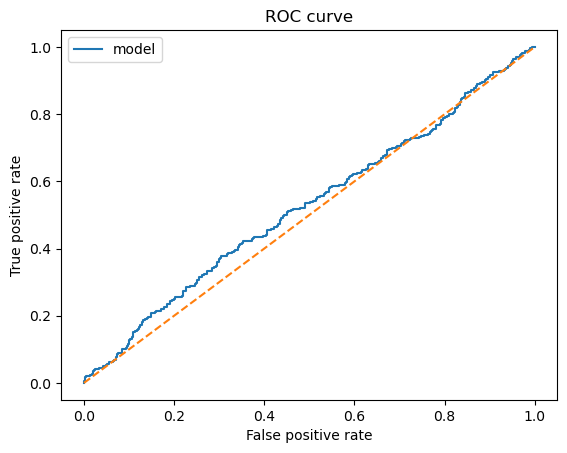

In [6]:
y = df.y_true.values
p = df.p_pred.values

fpr, tpr, _ = roc_curve(y, p)

plt.figure()
plt.plot(fpr, tpr, label="model")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

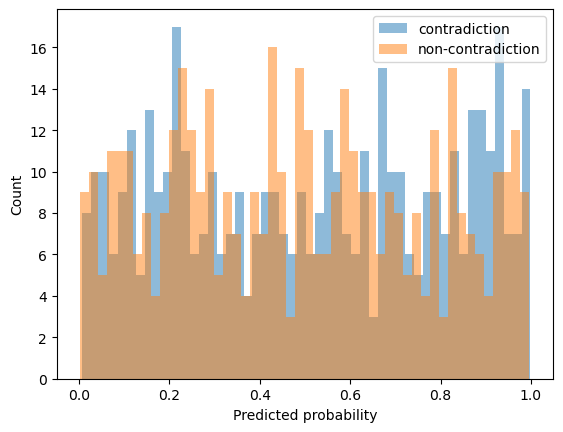

In [7]:
plt.figure()

plt.hist(df[df.y_true==1].p_pred, bins=50, alpha=0.5, label="contradiction")
plt.hist(df[df.y_true==0].p_pred, bins=50, alpha=0.5, label="non-contradiction")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()

Text(0.5, 0, 'Document category')

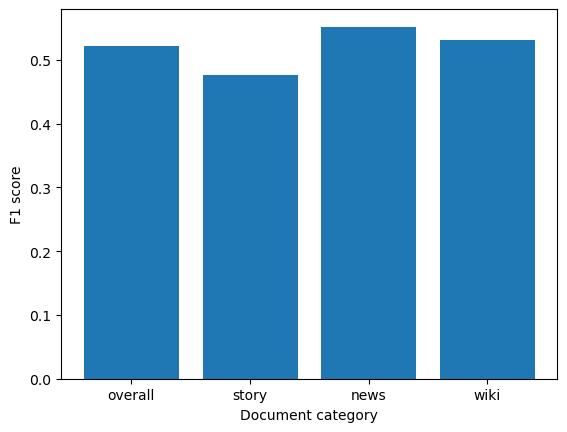

In [19]:
cats = list(metrics.keys())
f1_scores = [metrics[c]["f1"] for c in cats]

plt.figure()
plt.bar(cats, f1_scores)
plt.ylabel("F1 score")
plt.xlabel("Document category")
